In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import csv
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from dateutil import parser as dateparser

# We scrape across multiple topical sections to gather a robust baseline pool
# Replace section URLs with ID range for bulk harvesting
ID_START = 1780000
ID_END =  1790000

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}

# ADD after HEADERS dict:
session = requests.Session()
retries = Retry(total=3, backoff_factor=1, status_forcelist=[429, 500, 503])
session.mount("https://", HTTPAdapter(max_retries=retries))

def generate_article_links(id_start, id_end):
    """
    Step 1: Generates article URLs from a sequential ID range.
    No need to scrape section pages — IDs are predictable.
    """
    print(f"[*] Generating article URLs from ID {id_start} to {id_end}...")
    links_pool = [
        (f"https://www.bernama.com/en/news.php?id={article_id}", "News")
        for article_id in range(id_start, id_end + 1)
    ]
    print(f"[+] Total URLs generated: {len(links_pool)}")
    return links_pool


def parse_bernama_article(article_url, section="News"):
    """
    Step 2: Visits individual article URLs and extracts targeted data fields.
    """
    try:
        response = session.get(article_url, headers=HEADERS, timeout=15)
        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, 'html.parser')

        # 1. Headline (Matches <h1> tag with class 'fw-bold h2' from image_4dbff6.png)
        headline_tag = soup.find('h1', class_='fw-bold')
        if not headline_tag:
            headline_tag = soup.find('h1') # Fallback
        headline = headline_tag.get_text(strip=True) if headline_tag else None

        # 2. Publication Date (Matches <div class='text-start'> containing time from image_4dbf5b.png)
        date_div = soup.find('div', class_='text-start')
        raw_date = date_div.get_text(strip=True) if date_div else None
        try:
            pub_date = dateparser.parse(raw_date).strftime("%Y-%m-%d %H:%M") if raw_date else "N/A"
        except Exception:
            pub_date = raw_date or "N/A"

        # 4. Article Summary (Extracting the first clean paragraph of copy)
        summary = None
        # Look inside the primary article text container
        # Scope to article body first to avoid nav/footer text
        article_body = soup.find('div', class_='article-body')
        paragraphs = article_body.find_all('p') if article_body else soup.find_all('p')
        for p in paragraphs:
            text = p.get_text(strip=True)
            if len(text) > 40:
                summary = text
                break

        if headline:
            return {
                "headline": headline,
                "publication_date": pub_date,
                "section": section,
                "article_summary": summary,
                "url": article_url
            }
        return None

    except Exception:
        return None


if __name__ == "__main__":
    start_time = time.time()
    all_records = []

    csv_file = "/content/drive/MyDrive/bernama_baseline_raw.csv"
    fields = ["headline", "publication_date", "section", "article_summary", "url"]

    print("[*] Launching BERNAMA Resilient Baseline Pipeline...")

    # EDIT: replaced section scraping with ID range generation
    unique_links = generate_article_links(ID_START, ID_END)
    print(f"\n[+] Total article URLs queued: {len(unique_links)}")

    # checkpointing — skip already scraped URLs on re-run
    scraped_urls = set()
    file_mode = "w"
    try:
        with open(csv_file, encoding="utf-8") as f:
            scraped_urls = {row['url'] for row in csv.DictReader(f)}
        file_mode = "a"
        print(f"[*] Resuming — {len(scraped_urls)} articles already scraped, skipping.")
    except FileNotFoundError:
        file_mode = "w"
        print("[*] No existing file found — starting fresh.")

    unique_links = [(url, label) for url, label in unique_links if url not in scraped_urls]

    # this line is to test with only first 5 articles — DELETE this line when running full scrape
    # unique_links = unique_links[:1000]

    if unique_links:
        print(f"[*] Beginning deep extraction into '{csv_file}'...")
        with open(csv_file, mode=file_mode, newline="", encoding="utf-8") as file:
            writer = csv.DictWriter(file, fieldnames=fields)
            if file_mode == "w":
                writer.writeheader()

            # concurrent scraping replacing sequential for-loop
            with ThreadPoolExecutor(max_workers=5) as executor:
                futures = {
                    executor.submit(parse_bernama_article, url, label): url
                    for url, label in unique_links
                }
                completed = 0
                for future in as_completed(futures):
                    completed += 1
                    result = future.result()
                    if result:
                        all_records.append(result)
                        writer.writerow(result)
                        print(f"    [{completed}/{len(unique_links)}] Scraped: {result['headline'][:60]}...")

    end_time = time.time()
    print("\n" + "="*50)
    print(f"[SUCCESS] Scraped {len(all_records)} valid records successfully!")
    print(f"[METRIC] Total Execution Time: {end_time - start_time:.2f} seconds.")
    print(f"[DATA] Saved copy located at: '{csv_file}'")
    print("="*50)

[*] Launching BERNAMA Resilient Baseline Pipeline...
[*] Generating article URLs from ID 1780000 to 1790000...
[+] Total URLs generated: 10001

[+] Total article URLs queued: 10001
[*] Resuming — 97351 articles already scraped, skipping.
[*] Beginning deep extraction into '/content/drive/MyDrive/bernama_baseline_raw.csv'...
    [3/10000] Scraped: Go into vegetable, fruit farming - Dr Mahathir...
    [6/10000] Scraped: KLIBOR futures untraded at mid-day...
    [9/10000] Scraped: Singapore, US sign deal on infrastructure finance, market bu...
    [11/10000] Scraped: BIMB Investment expects 10-15 per cent growth for Shariah-ES...
    [20/10000] Scraped: MED discusses direction of air mobility industry with CAAM, ...
    [21/10000] Scraped: Functions of cooperative institutions need to be strengthene...
    [26/10000] Scraped: Labuan police intensify crime prevention efforts...
    [27/10000] Scraped: Sweden to raise retirement age...
    [29/10000] Scraped: Lithium Werks prioritises water

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/bernama_baseline_raw.csv")

total = len(df)
duplicates = df.duplicated(subset=['url']).sum()
unique = total - duplicates

print(f"Total rows: {total}")
print(f"Duplicate rows: {duplicates}")
print(f"Unique rows: {unique}")

if duplicates == 0:
    print("✅ No duplicates found!")
else:
    print(f"⚠️ Found {duplicates} duplicates!")
    # Show the duplicate rows
    print(df[df.duplicated(subset=['url'], keep=False)])

Total rows: 101212
Duplicate rows: 0
Unique rows: 101212
✅ No duplicates found!


# Parallel Processing Compute Engineer

In [ ]:
# ============================================================
# MEMBER 4:Parallel Processing Compute Engineer
# ============================================================

# Mount drive to access the shared raw dataset
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/bernama_baseline_raw.csv'
    PERF_BEFORE_PATH = '/content/drive/MyDrive/performance_before.csv'
    CLEANED_MEMBER3_PATH = '/content/drive/MyDrive/cleaned_data.csv'
    OUT_DIR = '/content/drive/MyDrive'
except ImportError:
    DATA_PATH = 'bernama_baseline_raw.csv'   # local / non-Colab fallback
    PERF_BEFORE_PATH = 'performance_before.csv'
    CLEANED_MEMBER3_PATH = 'cleaned_data.csv'
    OUT_DIR = '.'

import pandas as pd
import numpy as np
import time, os, threading
import multiprocessing as mp
import psutil
import matplotlib.pyplot as plt

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw records loaded: {len(df_raw):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw records loaded: 101,212


In [ ]:
# Load Member 3's official "before" benchmark
perf_before = pd.read_csv(PERF_BEFORE_PATH)
print("Member 3's official baseline benchmark:")
perf_before

Member 3's official baseline benchmark:


,technique,total_time_sec,records_processed,throughput_rec_per_sec,memory_mb
0,Baseline (Single-threaded),5.029732,101212,20122.742171,0.0


In [ ]:
# To confirm multiprocessing output is correct and equivalent to a sequential run on this machine
def baseline_clean(df):
    """Member 3's single-threaded cleaning pipeline (runs on the whole DataFrame at once)."""
    df = df.copy()

    # 1. remove duplicate articles (by URL)
    df.drop_duplicates(subset='url', inplace=True)

    # 2. strip whitespace from text fields
    str_cols = ['headline', 'section', 'article_summary', 'url']
    for col in str_cols:
        df[col] = df[col].str.strip()

    # 3. standardize publication_date
    df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')
    df.dropna(subset=['publication_date'], inplace=True)
    df['publication_date'] = df['publication_date'].dt.strftime('%Y-%m-%d %H:%M')

    # 4. validate url format
    valid_url_mask = df['url'].str.startswith('https://www.bernama.com')
    df = df[valid_url_mask]

    # 5. drop articles with very short summaries
    df = df[df['article_summary'].str.len() >= 40]

    # 6. standardize section text casing
    df['section'] = df['section'].str.title()

    # 7. derived columns
    df['pub_date_only'] = pd.to_datetime(df['publication_date']).dt.date
    df['pub_year'] = pd.to_datetime(df['publication_date']).dt.year
    df['pub_month'] = pd.to_datetime(df['publication_date']).dt.month
    df['headline_word_count'] = df['headline'].str.split().str.len()

    return df


process = psutil.Process(os.getpid())

mem_before = process.memory_info().rss / (1024 * 1024)
start_time = time.time()

df_clean_seq = baseline_clean(df_raw)

end_time = time.time()
mem_after = process.memory_info().rss / (1024 * 1024)

seq_total_time = end_time - start_time
seq_records = len(df_clean_seq)
seq_throughput = seq_records / seq_total_time
seq_mem = mem_after - mem_before

print(f"[BASELINE - Single-threaded]")
print(f"Total time       : {seq_total_time:.4f} s")
print(f"Records cleaned  : {seq_records:,}")
print(f"Throughput       : {seq_throughput:,.0f} records/sec")
print(f"Memory delta     : {seq_mem:.2f} MB")

[BASELINE - Single-threaded]
Total time       : 0.8773 s
Records cleaned  : 101,212
Throughput       : 115,367 records/sec
Memory delta     : 46.71 MB


In [ ]:
# Optimize with `multiprocessing` (parallel chunk processing)
def clean_chunk(df_chunk):
    """Row-independent cleaning steps applied to ONE chunk of the DataFrame.
    Runs inside a separate worker process."""
    df_chunk = df_chunk.copy()

    str_cols = ['headline', 'section', 'article_summary', 'url']
    for col in str_cols:
        df_chunk[col] = df_chunk[col].str.strip()

    df_chunk['publication_date'] = pd.to_datetime(df_chunk['publication_date'], errors='coerce')
    df_chunk.dropna(subset=['publication_date'], inplace=True)
    df_chunk['publication_date'] = df_chunk['publication_date'].dt.strftime('%Y-%m-%d %H:%M')

    valid_url_mask = df_chunk['url'].str.startswith('https://www.bernama.com')
    df_chunk = df_chunk[valid_url_mask]

    df_chunk = df_chunk[df_chunk['article_summary'].str.len() >= 40]

    df_chunk['section'] = df_chunk['section'].str.title()

    df_chunk['pub_date_only'] = pd.to_datetime(df_chunk['publication_date']).dt.date
    df_chunk['pub_year'] = pd.to_datetime(df_chunk['publication_date']).dt.year
    df_chunk['pub_month'] = pd.to_datetime(df_chunk['publication_date']).dt.month
    df_chunk['headline_word_count'] = df_chunk['headline'].str.split().str.len()

    return df_chunk


def split_dataframe(df, n_chunks):
    """Split a DataFrame into n_chunks roughly-equal, interleaved pieces."""
    return [df.iloc[i::n_chunks].copy() for i in range(n_chunks)]

In [ ]:
# Run the optimized pipeline with live CPU/memory profiling
N_WORKERS = mp.cpu_count()
print(f"Available CPU cores: {N_WORKERS}")

monitor_log = {'t': [], 'cpu_percpu': [], 'mem_mb': []}
stop_event = threading.Event()

def resource_monitor(interval=0.2):
    proc = psutil.Process(os.getpid())
    t0 = time.time()
    while not stop_event.is_set():
        monitor_log['t'].append(time.time() - t0)
        monitor_log['cpu_percpu'].append(psutil.cpu_percent(percpu=True))
        monitor_log['mem_mb'].append(proc.memory_info().rss / (1024 * 1024))
        time.sleep(interval)

mon_thread = threading.Thread(target=resource_monitor, daemon=True)
mon_thread.start()

mem_before = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_time = time.time()

# 1. cheap global dedup BEFORE splitting (keeps chunks disjoint -> correctness preserved)
df_dedup = df_raw.drop_duplicates(subset='url')

# 2. split into N chunks, one per core
chunks = split_dataframe(df_dedup, N_WORKERS)

# 3. clean each chunk in parallel
with mp.Pool(processes=N_WORKERS) as pool:
    cleaned_chunks = pool.map(clean_chunk, chunks)

# 4. merge results back together
df_clean_par = pd.concat(cleaned_chunks, ignore_index=True)

end_time = time.time()

stop_event.set()
mon_thread.join()

par_total_time = end_time - start_time
par_records = len(df_clean_par)
par_throughput = par_records / par_total_time
par_mem = max(monitor_log['mem_mb']) - mem_before

print(f"[OPTIMIZED - multiprocessing, {N_WORKERS} worker(s)]")
print(f"Total time        : {par_total_time:.4f} s")
print(f"Records cleaned   : {par_records:,}")
print(f"Throughput        : {par_throughput:,.0f} records/sec")
print(f"Peak memory delta : {par_mem:.2f} MB")

Available CPU cores: 2
[OPTIMIZED - multiprocessing, 2 worker(s)]
Total time        : 1.4576 s
Records cleaned   : 101,212
Throughput        : 69,439 records/sec
Peak memory delta : 96.35 MB


In [ ]:
# Verify whether baseline and optimized outputs match
df_member3 = pd.read_csv(CLEANED_MEMBER3_PATH)

print("Sequential cross-check records :", len(df_clean_seq))
print("Member 3 cleaned_data.csv      :", len(df_member3))
print("Optimized (multiprocessing)    :", len(df_clean_par))

same_count_seq = len(df_clean_seq) == len(df_clean_par)
same_urls_seq = set(df_clean_seq['url']) == set(df_clean_par['url'])

same_count_m3 = len(df_member3) == len(df_clean_par)
same_urls_m3 = set(df_member3['url']) == set(df_clean_par['url'])

print("\nvs sequential cross-check -> same count:", same_count_seq, "| same URLs:", same_urls_seq)
print("vs Member 3 cleaned_data.csv -> same count:", same_count_m3, "| same URLs:", same_urls_m3)

Sequential cross-check records : 101212
Member 3 cleaned_data.csv      : 101212
Optimized (multiprocessing)    : 101212

vs sequential cross-check -> same count: True | same URLs: True
vs Member 3 cleaned_data.csv -> same count: True | same URLs: True


In [ ]:
# Save the cleaned dataset
csv_path = os.path.join(OUT_DIR, 'bernama_cleaned_optimized.csv')
json_path = os.path.join(OUT_DIR, 'bernama_cleaned_optimized.json')

df_clean_par.to_csv(csv_path, index=False)
df_clean_par.to_json(json_path, orient='records', lines=True)

print(f"Saved {len(df_clean_par):,} cleaned records to:")
print(f"  {csv_path}")
print(f"  {json_path}")

Saved 101,212 cleaned records to:
  /content/drive/MyDrive/bernama_cleaned_optimized.csv
  /content/drive/MyDrive/bernama_cleaned_optimized.json


In [ ]:
# Performance comparison: Before vs After
perf_after = pd.DataFrame([{
    'technique': f'Optimized (multiprocessing, {N_WORKERS} workers)',
    'total_time_sec': par_total_time,
    'records_processed': par_records,
    'throughput_rec_per_sec': par_throughput,
    'memory_mb': par_mem,
}])

perf_after.to_csv(os.path.join(OUT_DIR, 'performance_after.csv'), index=False)

# perf_before was loaded from Member 3's performance_before.csv in Step 1
perf_compare = pd.concat([perf_before, perf_after], ignore_index=True)
perf_compare['speedup_x'] = perf_compare['total_time_sec'].iloc[0] / perf_compare['total_time_sec']
perf_compare.to_csv(os.path.join(OUT_DIR, 'performance_comparison.csv'), index=False)
perf_compare

,technique,total_time_sec,records_processed,throughput_rec_per_sec,memory_mb,speedup_x
0,Baseline (Single-threaded),5.029732,101212,20122.742171,0.000000,1.000000
1,"Optimized (multiprocessing, 2 workers)",1.457575,101212,69438.607068,96.347656,3.450753


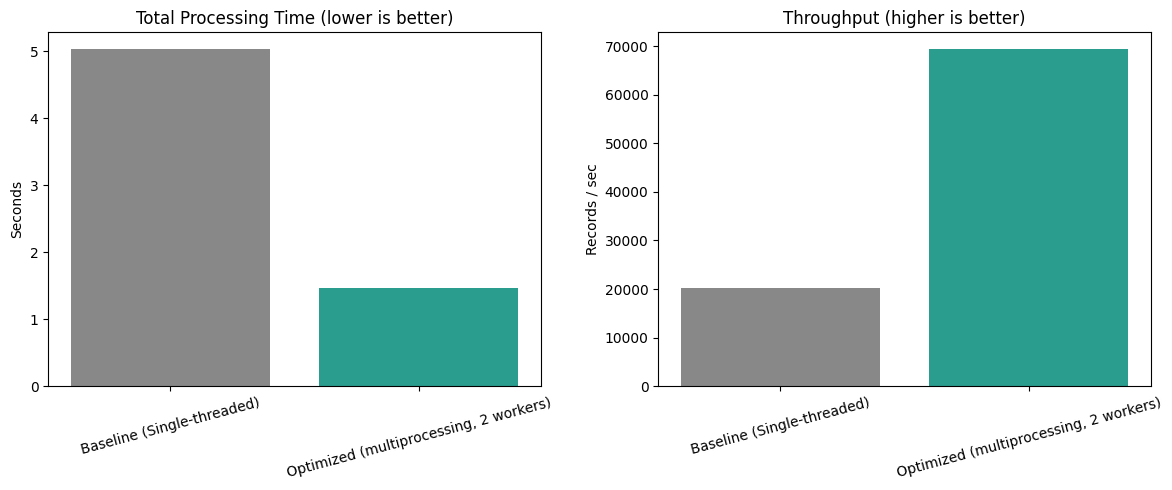

Speedup: 3.45x  (using 2 worker process(es) on this machine)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#888888', '#2a9d8f']

axes[0].bar(perf_compare['technique'], perf_compare['total_time_sec'], color=colors)
axes[0].set_title('Total Processing Time (lower is better)')
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(perf_compare['technique'], perf_compare['throughput_rec_per_sec'], color=colors)
axes[1].set_title('Throughput (higher is better)')
axes[1].set_ylabel('Records / sec')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'performance_comparison.png'), dpi=150)
plt.show()

print(f"Speedup: {perf_compare['speedup_x'].iloc[1]:.2f}x  "
      f"(using {N_WORKERS} worker process(es) on this machine)")

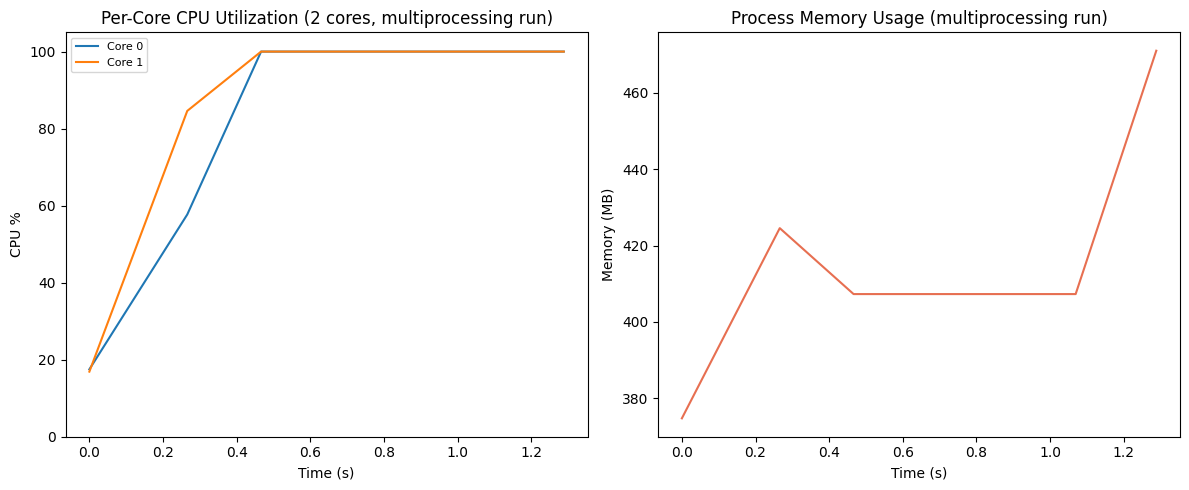

In [ ]:
# Hardware utilization profile during the optimized run
cpu_arr = np.array(monitor_log['cpu_percpu'])  # shape: (samples, cores)
t_arr = np.array(monitor_log['t'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for core_idx in range(cpu_arr.shape[1]):
    axes[0].plot(t_arr, cpu_arr[:, core_idx], label=f'Core {core_idx}')
axes[0].set_title(f'Per-Core CPU Utilization ({N_WORKERS} cores, multiprocessing run)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('CPU %')
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=8)

axes[1].plot(t_arr, monitor_log['mem_mb'], color='#e76f51')
axes[1].set_title('Process Memory Usage (multiprocessing run)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Memory (MB)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hardware_utilization.png'), dpi=150)
plt.show()